### Cross Product
The cross product is an operation between two 3-element vectors that produces a third vector perpendicular to both of them.
Its magnitude represents the area of the parallelogram formed by the two vectors and is given by

$$
\|\mathbf{a} \times \mathbf{b}\| = \|\mathbf{a}\|\,\|\mathbf{b}\|\sin(\theta_{ab})
$$

Mathematically,

$$
\mathbf{a} \times \mathbf{b} =
\begin{bmatrix}
a_2b_3 - a_3b_2 \\
a_3b_1 - a_1b_3 \\
a_1b_2 - a_2b_1
\end{bmatrix}
$$

We use the cross product when we need to find a perpendicular direction or rotational effect, such as torque, angular momentum, or the normal to a surface.

In [1]:
# Import Numpy and Matplotlib Modules
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Create two 3D Vectors
a  = [ -3,  2, 5 ]
b  = [  4, -3, 0 ]

In [3]:
# Method-1: Vectors Cross Product
aCrossb_1 = [a[1]*b[2] - a[2]*b[1],
            -(a[0]*b[2] - a[2]*b[0]),
            a[0]*b[1] - a[1]*b[0]]
print(f"a x b = {aCrossb_1}")

a x b = [15, 20, 1]


In [4]:
# Method-2: Vectors Cross Product
aCrossb_2 = np.cross(a, b)
print(f"a x b = {aCrossb_2}")

a x b = [15 20  1]


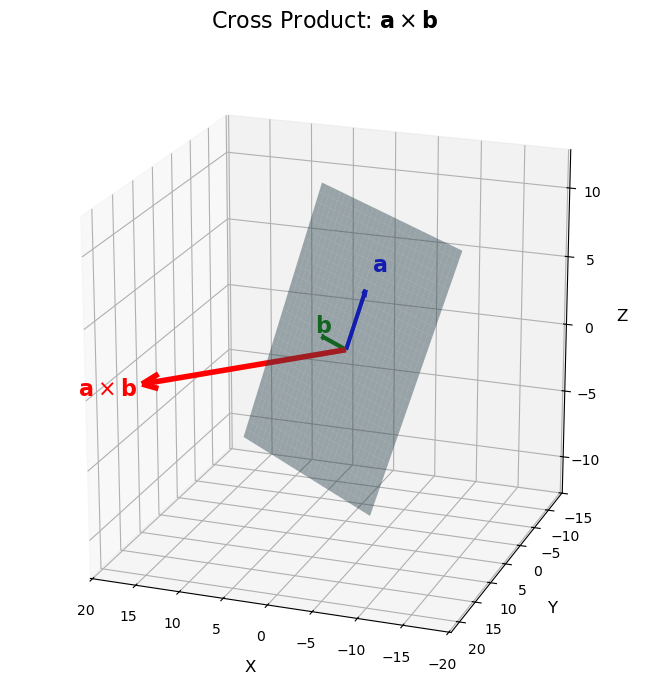

In [6]:
# Plot the vectors a, b, and their cross product vector
a = np.array(a)
b = np.array(b)

# Create 3D figure
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Determine the size of the vectors
a_len = np.linalg.norm(a)
b_len = np.linalg.norm(b)
max_vector_length = max(a_len, b_len)

# Create a large plane dynamically
a_hat = a / a_len            # Unit vector along a
b_hat = b / b_len            # Unit vector along b

# Plane size relative to vector size
plane_size = 2.2 * max_vector_length

s = np.linspace(-plane_size, plane_size, 30)
t = np.linspace(-plane_size, plane_size, 30)
S, T = np.meshgrid(s, t)

# Points on plane
X = S * a_hat[0] + T * b_hat[0]
Y = S * a_hat[1] + T * b_hat[1]
Z = S * a_hat[2] + T * b_hat[2]

# Draw plane
ax.plot_surface(X, Y, Z, color='skyblue', alpha=0.45, edgecolor='none')

# Draw vector a
ax.quiver(0, 0, 0, a[0], a[1], a[2], color='blue', linewidth=3, arrow_length_ratio=0.10)

# Draw vector b
ax.quiver(0, 0, 0, b[0], b[1], b[2], color='green', linewidth=3, arrow_length_ratio=0.10)

# Draw cross product vector of a and b
ax.quiver(0, 0, 0, aCrossb_2[0], aCrossb_2[1], aCrossb_2[2], color='red', linewidth=4, arrow_length_ratio=0.08)

# Dynamic label positions
# Position labels slightly beyond the vector endpoints
label_scale = 1.3

a_label = a * label_scale
b_label = b * label_scale
cross_label = aCrossb_2 * label_scale

# Vector labels
ax.text( a_label[0], a_label[1], a_label[2], r'$\mathbf{a}$', color='blue', fontsize=16, fontweight='bold')
ax.text(b_label[0], b_label[1], b_label[2], r'$\mathbf{b}$', color='green', fontsize=16, fontweight='bold')
ax.text(cross_label[0], cross_label[1], cross_label[2], r'$\mathbf{a}\times\mathbf{b}$', color='red',
        fontsize=16, fontweight='bold')

# Determine plot limits dynamically
# Include vectors and plane
all_x = np.concatenate([X.ravel(), [0, a[0], b[0], aCrossb_2[0]]])
all_y = np.concatenate([Y.ravel(), [0, a[1], b[1], aCrossb_2[1]]])
all_z = np.concatenate([Z.ravel(), [0, a[2], b[2], aCrossb_2[2]]])

x_min, x_max = all_x.min(), all_x.max()
y_min, y_max = all_y.min(), all_y.max()
z_min, z_max = all_z.min(), all_z.max()

# Add padding
padding = 0.08

x_range = x_max - x_min
y_range = y_max - y_min
z_range = z_max - z_min

ax.set_xlim(x_min - padding * x_range, x_max + padding * x_range)
ax.set_ylim(y_min - padding * y_range, y_max + padding * y_range)
ax.set_zlim(z_min - padding * z_range, z_max + padding * z_range)

# Axis labels
ax.set_xlabel('X', fontsize=12, labelpad=8)
ax.set_ylabel('Y', fontsize=12, labelpad=8)
ax.set_zlabel('Z', fontsize=12, labelpad=8)

# Appearance
ax.set_box_aspect([1, 1, 1])
ax.grid(True, alpha=0.35)
ax.set_title(r'Cross Product: $\mathbf{a}\times\mathbf{b}$', fontsize=16, pad=20)

# Figure spacing
fig.subplots_adjust(left=0.02, right=0.95, bottom=0.02, top=0.92)

# Viewing angle
ax.view_init(
    elev=20,
    azim=110
)

plt.show()